## Steps to do EDA
1. Identification of variables and data types
2. Analyzing the basic metrics
3. Non-Graphical Univariate Analysis
4. Graphical Univariate Analysis
5. Bivariate Analysis
6. Variable transformations
7. Missing value treatment
8. Outlier treatment
9. Correlation Analysis
10. Dimensionality Reduction

In [1]:
import pandas as pd
from pandas_profiling import ProfileReport
import numpy as np 
import matplotlib.pyplot as plt
import random
import seaborn as sns
%matplotlib Inline


In [2]:
data_set = pd.read_csv("Titanic dataset.csv")
#pd.set_option("display.max_rows", 1000)
data_set.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,0,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [3]:
profile = ProfileReport(data_set, title="Titanic data set Profiling Report")

In [4]:
profile

In [5]:
profile.to_file("your_report.html")

In [4]:
data_set.Pclass.count()

418

In [5]:
duplicat = data_set.duplicated()
data_set[duplicat].sum()


PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Cabin          0.0
Embarked       0.0
dtype: float64

In [6]:
data_set.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [8]:
data_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.358852,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.480238,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [9]:
data_set.select_dtypes('object').describe()

,Name,Sex,Ticket,Cabin,Embarked
count,418,418,418,91,418
unique,418,2,363,76,3
top,"Willard, Miss. Constance",male,PC 17608,B57 B59 B63 B66,S
freq,1,266,5,3,270


In [10]:
data_set.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [11]:
data_set.select_dtypes("object").columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

## Missinng values

In [12]:
col = data_set.columns

In [13]:
for i in col:
    print("{}".format(i),"\t", data_set[i].isna().sum())

PassengerId 	 0
Survived 	 0
Pclass 	 0
Name 	 0
Sex 	 0
Age 	 86
SibSp 	 0
Parch 	 0
Ticket 	 0
Fare 	 1
Cabin 	 327
Embarked 	 0


In [14]:
data_set.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [15]:
data_set.apply(lambda x: sum(x.isnull()),axis=0)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<AxesSubplot:>

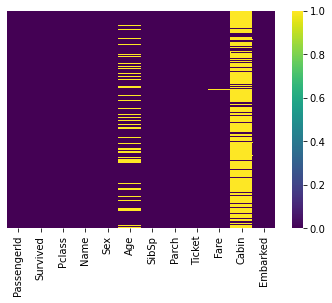

In [16]:
sns.heatmap(data_set.isna(), yticklabels=False, cmap='viridis')

In [17]:
#displayind the null values from all rows condition is "or"
data_set[data_set.isna().any(axis=1)].sample(5, random_state=2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
345,1237,1,3,"Abelseth, Miss. Karen Marie",female,16.0,0,0,348125,7.6500,NaN,S
273,1165,1,3,"Lennon, Miss. Mary",female,NaN,1,0,370371,15.5000,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
229,1121,0,2,"Hocking, Mr. Samuel James Metcalfe",male,36.0,0,0,242963,13.0000,NaN,S
86,978,1,3,"Barry, Miss. Julia",female,27.0,0,0,330844,7.8792,NaN,Q


In [18]:
#displaying the all rowes with both rows age and cabin are null
a = data_set[["Age", "Cabin"]].isnull()

count = -1
con = list()
for i in a.values:
    count += 1
    if [True, True] == list(i):
        con.append(count)
        
null_rows = data_set.iloc[con]
null_rows.sample(5, random_state = 2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
148,1040,0,1,"Crafton, Mr. John Bertram",male,NaN,0,0,113791,26.5500,NaN,S
10,902,0,3,"Ilieff, Mr. Ylio",male,NaN,0,0,349220,7.8958,NaN,S
151,1043,0,3,"Matinoff, Mr. Nicola",male,NaN,0,0,349255,7.8958,NaN,C
83,975,0,3,"Demetri, Mr. Marinko",male,NaN,0,0,349238,7.8958,NaN,S
384,1276,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S


## unique

In [19]:
data_set.Sex.unique()

array(['male', 'female'], dtype=object)

In [20]:
for i in col:
    print(i, "  ", data_set[i].nunique())

PassengerId    418
Survived    2
Pclass    3
Name    418
Sex    2
Age    79
SibSp    7
Parch    8
Ticket    363
Fare    169
Cabin    76
Embarked    3


In [21]:
for i in ['Survived', 'Pclass', 'Sex', 'Parch', 'Embarked']:
    print(data_set[i].value_counts())

0    268
1    150
Name: Survived, dtype: int64
3    218
1    107
2     93
Name: Pclass, dtype: int64
male      266
female    152
Name: Sex, dtype: int64
0    324
1     52
2     33
3      3
4      2
9      2
5      1
6      1
Name: Parch, dtype: int64
S    270
C    102
Q     46
Name: Embarked, dtype: int64


In [22]:
data_set["Cabin"].nunique()

76

In [23]:
data_set['Cabin'].value_counts()

B57 B59 B63 B66    3
C89                2
C101               2
C78                2
C80                2
                  ..
B58 B60            1
E52                1
A11                1
D38                1
C132               1
Name: Cabin, Length: 76, dtype: int64

## Filtering based on condition

In [24]:
data_set[data_set["Sex"] == "male"]. tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
407,1299,0,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [25]:
data_set[(data_set["Age"].isna()) & (data_set["Cabin"].isna())  ].tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
408,1300,1,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
410,1302,1,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [26]:
data_set.select_dtypes("object").columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

## filling missing values

In [27]:
#data_set['Age'].where(data_set['Age'].notnull(), "Null", inplace=True)
#data_set['Age'].head(10)

In [28]:
#replacing null values in age using random values in the Age column
random_sample = data_set['Age'].dropna().sample(data_set['Age'].isnull().sum(), random_state=0)

In [29]:
#to validate the results
random_sample.index = data_set[data_set['Age'].isna()].index

In [30]:
data_set['Age'].isna().sum()

86

In [31]:
data_set.loc[data_set['Age'].isna(), ["Age"]] = random_sample

In [32]:
data_set['Age'].isna().sum()

0

In [33]:
data_set["Cabin"].replace(np.nan, "Null", inplace=True)
data_set['Cabin']

0      Null
1      Null
2      Null
3      Null
4      Null
       ... 
413    Null
414    C105
415    Null
416    Null
417    Null
Name: Cabin, Length: 418, dtype: object

In [34]:
data_set.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin          0
Embarked       0
dtype: int64

## converting dtype

In [35]:
for j, i in enumerate(data_set['Cabin']):
    data_set.at[j,'Cabin'] = i[0]

data_set["Cabin"].sample()

81    C
Name: Cabin, dtype: object

In [36]:
data_set["Cabin"].astype('object')

0      N
1      N
2      N
3      N
4      N
      ..
413    N
414    C
415    N
416    N
417    N
Name: Cabin, Length: 418, dtype: object

In [37]:
data_set['Cabin_null'] = np.where(data_set['Cabin'] == 'N', 1, 0)

In [38]:
data_set['Cabin_null']

0      1
1      1
2      1
3      1
4      1
      ..
413    1
414    0
415    1
416    1
417    1
Name: Cabin_null, Length: 418, dtype: int32

## GroupBy

In [39]:
# To see percentage of people survived based on the cabin_null
data_set.groupby(['Survived'])['Cabin_null'].mean()

Survived
0    0.820896
1    0.713333
Name: Cabin_null, dtype: float64

In [40]:
data_set.groupby(['Survived'])['Pclass'].count().sort_values(ascending = False)

Survived
0    268
1    150
Name: Pclass, dtype: int64

In [41]:
data_set.groupby(['Pclass'])['Fare'].count()

Pclass
1    107
2     93
3    217
Name: Fare, dtype: int64

<AxesSubplot:xlabel='Cabin'>

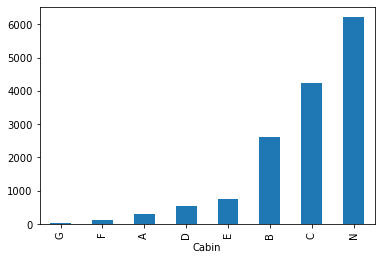

In [42]:
data_set.groupby(['Cabin'])['Fare'].sum().sort_values().plot.bar()

In [43]:
# grouping by sex
z = data_set.groupby(["Sex"])

In [44]:
# accessing values by category in sex 
z.get_group('female')["Survived"].value_counts()

1    144
0      8
Name: Survived, dtype: int64

In [45]:
data_set.groupby(["Sex"]).sum()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_null
Sex,,,,,,,,
female,166712,144,326,4603.59,86,91,7561.6502,108
male,293297,6,621,8055.16,101,73,7294.8874,219


## Outliers
> To find outliers we need to find the boundaries of the data that means the distribution of it check below upper_limit and lower_limit are the boundaries. \
> Outliers can also be finded by some graphs ex. boxplot, hist, scatter plot etc. \
> After finding the outliers we need to perform operations to handel it. \

   ### some ways to find outliers
    1. Using Z-Score to Detect Outliers
    2. Using the Interquartile Range to Create Outlier Fences
    3. Finding Outliers with Hypothesis Tests
    

<AxesSubplot:ylabel='Fare'>

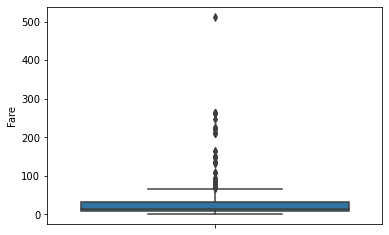

In [46]:
sns.boxplot(y="Fare", data=data_set)

<AxesSubplot:ylabel='Age'>

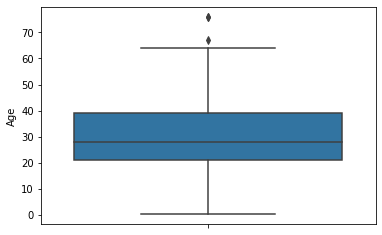

In [47]:
sns.boxplot(y="Age", data=data_set)

In [48]:
# finding outliers in fair column
iqr = data_set.Fare.quantile(0.75) - data_set.Fare.quantile(0.25)
iqr

23.6042

In [49]:
data_set.Fare.describe()

count    417.000000
mean      35.627188
std       55.907576
min        0.000000
25%        7.895800
50%       14.454200
75%       31.500000
max      512.329200
Name: Fare, dtype: float64

In [342]:
lower_boundary = data_set.Fare.mean() - 3 * data_set.Fare.std() #(iqr * 3)
upper_boundary = data_set.Fare.mean() + 3 * data_set.Fare.std() #(iqr * 3)
print(lower_boundary), print(upper_boundary),print(data_set.Fare.mean()),  

-132.09554005071288
203.3499170291301
35.6271884892086


(None, None, None)

In [50]:
lower_boundary = data_set.Fare.quantile(0.25) - 1.5 * iqr #(iqr * 3)
upper_boundary = data_set.Fare.quantile(0.25) + 1.5 * iqr #(iqr * 3)
print(lower_boundary)
print(upper_boundary)
print(data_set.Fare.mean())  

-27.5105
43.3021
35.6271884892086


In [51]:
a = data_set[(data_set["Fare"] >= upper_boundary) | (data_set["Fare"] <= lower_boundary)]

In [52]:
len(a.Fare)

85

<AxesSubplot:ylabel='Fare'>

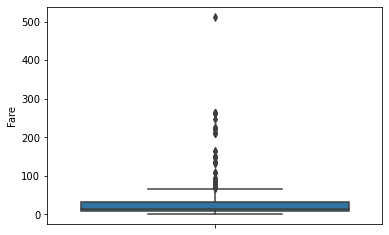

In [53]:
sns.boxplot(y="Fare", data=data_set)

C:\Users\HP\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Fare', ylabel='Density'>

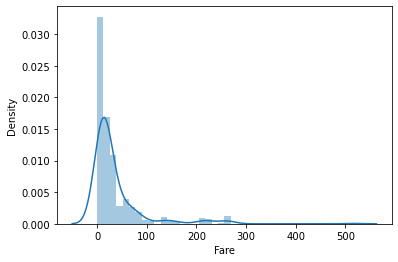

In [54]:
sns.distplot(data_set.Fare, bins=40)

In [55]:
for i in data_set.Fare:
    if i > upper_boundary or i < lower_boundary:
        data_set.replace(i, data_set.Fare.mean(), inplace=True)
        

<AxesSubplot:ylabel='Fare'>

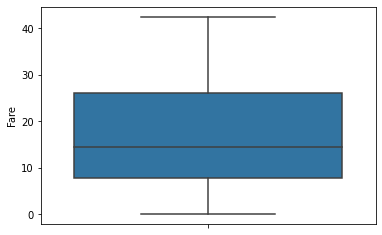

In [56]:
sns.boxplot(y="Fare", data=data_set)

C:\Users\HP\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Fare', ylabel='Density'>

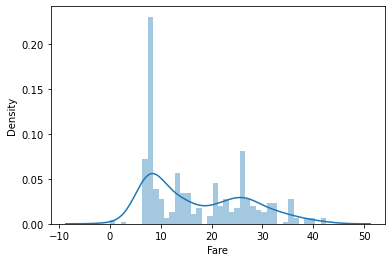

In [57]:
sns.distplot(data_set.Fare, bins=40)

<AxesSubplot:ylabel='Age'>

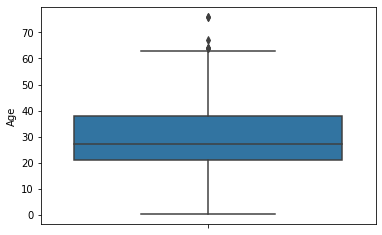

In [58]:
sns.boxplot(y="Age", data=data_set)

C:\Users\HP\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

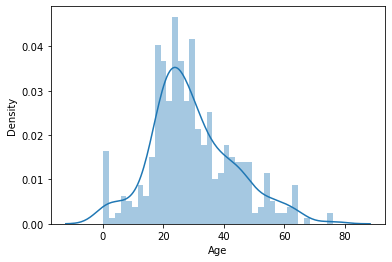

In [59]:
sns.distplot(data_set.Age, bins=40)

In [60]:
iqr_age = data_set.Age.quantile(0.75) - data_set.Age.quantile(0.25)
iqr_age

17.0

In [61]:
lower_boundary_age = data_set.Age.quantile(0.25) - 1.5 * iqr_age #(iqr * 3)
upper_boundary_age = data_set.Age.quantile(0.25) + 1.5 * iqr_age #(iqr * 3)
print(lower_boundary_age)
print(upper_boundary_age)
print(data_set.Age.mean())  

-4.5
46.5
29.62059258437718


In [62]:
data_set[(data_set["Age"] >= upper_boundary_age) |(data_set["Age"] <= lower_boundary_age)].Age

1      47.0
2      62.0
13     63.0
14     47.0
20     55.0
22     47.0
24     48.0
33     48.0
65     57.0
67     47.0
77     55.0
81     67.0
82     49.0
91     76.0
96     76.0
114    63.0
121    47.0
131    53.0
142    61.0
148    58.0
152    60.5
166    48.0
177    54.0
179    64.0
193    61.0
202    47.0
217    57.0
219    55.0
224    53.0
225    48.0
236    64.0
239    48.0
240    55.0
249    63.0
265    51.0
266    63.0
286    48.0
293    53.0
305    64.0
308    55.0
314    55.0
316    57.0
330    48.0
342    47.0
343    58.0
353    49.0
356    59.0
372    49.0
374    54.0
378    55.0
387    57.0
391    51.0
393    47.0
397    48.0
Name: Age, dtype: float64

In [63]:
for i in data_set.Age:
    if i > upper_boundary_age or i < 0:
        data_set.replace(i, data_set.Age.mean(), inplace=True)
        

In [64]:
len(data_set[(data_set["Age"] >= upper_boundary_age) |(data_set["Age"] <= lower_boundary_age)].Age)

0

<AxesSubplot:ylabel='Age'>

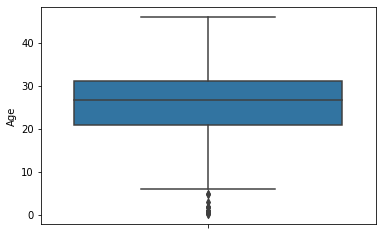

In [65]:
sns.boxplot(y="Age", data=data_set)

In [66]:
data_set[(data_set["Age"] >= upper_boundary_age) |(data_set["Age"] <= lower_boundary_age)].Age

Series([], Name: Age, dtype: float64)

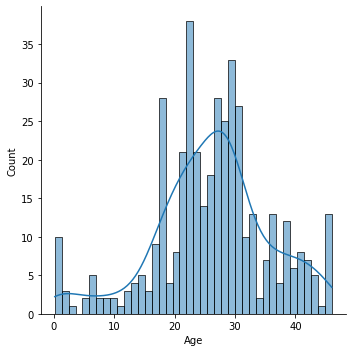

In [67]:
sns.displot(data_set.Age, bins=40, kde = True)

## Basic Visualization

<AxesSubplot:>

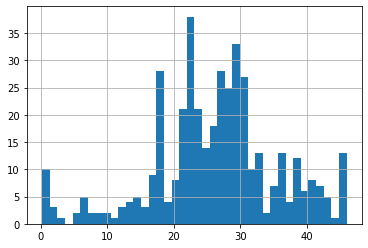

In [68]:
data_set.Age.hist(bins=40)

<AxesSubplot:ylabel='Age'>

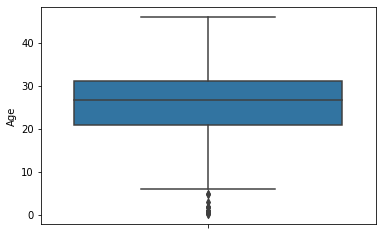

In [69]:
sns.boxplot(y ='Age', data=data_set)

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

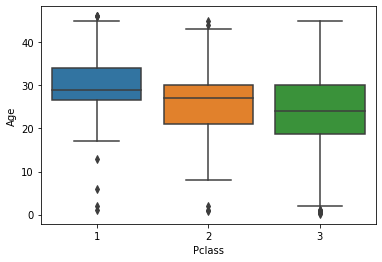

In [70]:
sns.boxplot(x="Pclass",y="Age", data=data_set)

<AxesSubplot:xlabel='Survived', ylabel='count'>

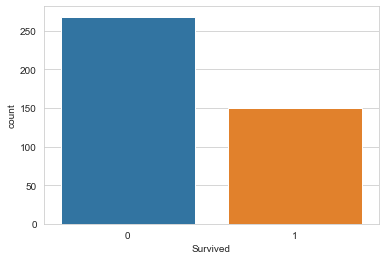

In [71]:
sns.set_style("whitegrid")
sns.countplot(x='Survived', data=data_set)

<AxesSubplot:xlabel='Sex', ylabel='count'>

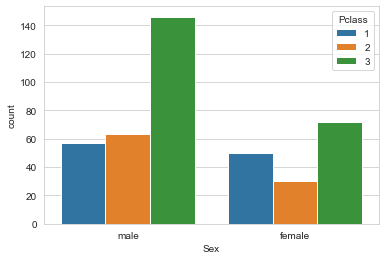

In [72]:
sns.countplot(x='Sex', hue="Pclass" ,data=data_set)

<AxesSubplot:xlabel='SibSp', ylabel='count'>

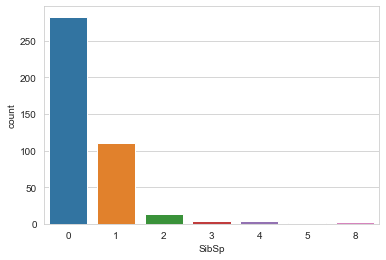

In [73]:
sns.countplot(x="SibSp", data=data_set)

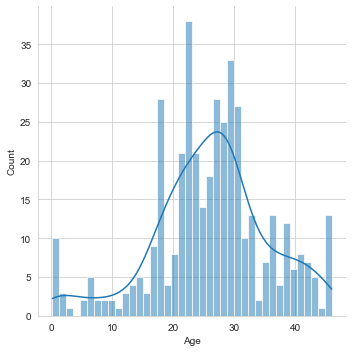

In [74]:
sns.displot(data_set.Age, bins= 40, kde=True)

C:\Users\HP\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Age', ylabel='Density'>

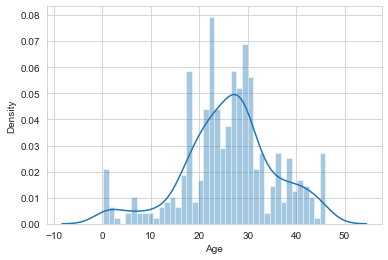

In [75]:
sns.distplot(data_set.Age, bins=40)

<AxesSubplot:>

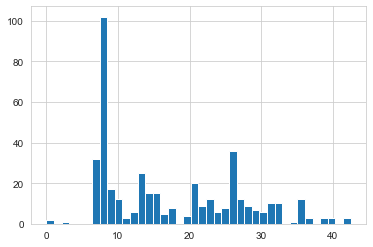

In [76]:
data_set.Fare.hist(bins=40)

<AxesSubplot:xlabel='Cabin', ylabel='Fare'>

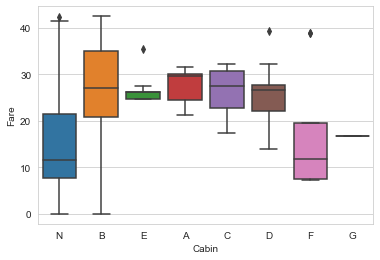

In [77]:
sns.boxplot(y="Fare", x="Cabin",data=data_set)

In [78]:
data_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_null
0,892,0,3,"Kelly, Mr. James",male,34.500000,0,0,330911,7.8292,N,Q,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,29.620593,1,0,363272,7.0000,N,S,1
2,894,0,2,"Myles, Mr. Thomas Francis",male,29.287972,0,0,240276,9.6875,N,Q,1
3,895,0,3,"Wirz, Mr. Albert",male,27.000000,0,0,315154,8.6625,N,S,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000000,1,1,3101298,12.2875,N,S,1


## Encoding

In [79]:
from sklearn import preprocessing

In [80]:
label_encoding = preprocessing.LabelEncoder()

In [81]:
data_set["encoded_sex"] = label_encoding.fit_transform(data_set.Sex)

In [82]:
data_set.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Cabin_null       int32
encoded_sex      int32
dtype: object

In [83]:
categorical_cols = data_set.select_dtypes("object").columns.tolist()

In [84]:
categorical_cols

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [85]:
data_set[categorical_cols].nunique()

Name        418
Sex           2
Ticket      363
Cabin         8
Embarked      3
dtype: int64

In [115]:
from sklearn.preprocessing import OneHotEncoder
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200

In [116]:
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')

In [117]:
encoder.fit(data_set[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse=False)

In [143]:
encoded_cols = list(encoder.get_feature_names(categorical_cols))
len(encoded_cols)

794

In [146]:
data_set[encoded_cols] = encoder.transform(data_set[categorical_cols])

In [147]:
data_set

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_null,encoded_sex,"Name_Abbott, Master. Eugene Joseph","Name_Abelseth, Miss. Karen Marie","Name_Abelseth, Mr. Olaus Jorgensen","Name_Abrahamsson, Mr. Abraham August Johannes","Name_Abrahim, Mrs. Joseph (Sophie Halaut Easu)","Name_Aks, Master. Philip Frank","Name_Aldworth, Mr. Charles Augustus","Name_Allison, Mr. Hudson Joshua Creighton","Name_Andersen, Mr. Albert Karvin","Name_Andersson, Miss. Ida Augusta Margareta","Name_Andersson, Mr. Johan Samuel","Name_Andrew, Mr. Frank Thomas","Name_Angheloff, Mr. Minko","Name_Angle, Mr. William A","Name_Aronsson, Mr. Ernst Axel Algot","Name_Ashby, Mr. John","Name_Asplund, Master. Carl Edgar","Name_Asplund, Master. Filip Oscar","Name_Asplund, Mr. Carl Oscar Vilhelm Gustafsson","Name_Asplund, Mr. Johan Charles","Name_Assaf Khalil, Mrs. Mariana (Miriam"")""","Name_Assaf, Mr. Gerios","Name_Assam, Mr. Ali","Name_Astor, Col. John Jacob","Name_Baccos, Mr. Raffull","Name_Badman, Miss. Emily Louisa","Name_Baimbrigge, Mr. Charles Robert","Name_Barry, Miss. Julia","Name_Beattie, Mr. Thomson","Name_Beauchamp, Mr. Henry James","Name_Becker, Miss. Ruth Elizabeth","Name_Becker, Mrs. Allen Oliver (Nellie E Baumgardner)","Name_Bentham, Miss. Lilian W","Name_Betros, Master. Seman","Name_Bird, Miss. Ellen","Name_Birnbaum, Mr. Jakob","Name_Bjorklund, Mr. Ernst Herbert","Name_Bonnell, Miss. Caroline","Name_Borebank, Mr. John James","Name_Botsford, Mr. William Hull","Name_Boulos, Master. Akar","Name_Bowen, Miss. Grace Scott","Name_Bowenur, Mr. Solomon","Name_Bradley, Miss. Bridget Delia","Name_Brady, Mr. John Bertram","Name_Braf, Miss. Elin Ester Maria","Name_Brandeis, Mr. Emil","Name_Brobeck, Mr. Karl Rudolf","Name_Brown, Miss. Edith Eileen","Name_Brown, Mrs. John Murray (Caroline Lane Lamson)","Name_Bryhl, Miss. Dagmar Jenny Ingeborg","Name_Buckley, Miss. Katherine","Name_Buckley, Mr. Daniel","Name_Bucknell, Mrs. William Robert (Emma Eliza Ward)","Name_Burns, Miss. Mary Delia","Name_Cacic, Miss. Manda","Name_Cacic, Mr. Jego Grga","Name_Caldwell, Mr. Albert Francis","Name_Canavan, Mr. Patrick","Name_Candee, Mrs. Edward (Helen Churchill Hungerford)","Name_Caram, Mr. Joseph","Name_Cardeza, Mrs. James Warburton Martinez (Charlotte Wardle Drake)","Name_Carlsson, Mr. Carl Robert","Name_Carr, Miss. Jeannie","Name_Carrau, Mr. Jose Pedro","Name_Carver, Mr. Alfred John","Name_Case, Mr. Howard Brown","Name_Cassebeer, Mrs. Henry Arthur Jr (Eleanor Genevieve Fosdick)","Name_Cavendish, Mrs. Tyrell William (Julia Florence Siegel)","Name_Chaffee, Mrs. Herbert Fuller (Carrie Constance Toogood)","Name_Chapman, Mrs. John Henry (Sara Elizabeth Lawry)","Name_Chaudanson, Miss. Victorine","Name_Chevre, Mr. Paul Romaine","Name_Chisholm, Mr. Roderick Robert Crispin","Name_Christy, Mrs. (Alice Frances)","Name_Chronopoulos, Mr. Demetrios","Name_Clark, Mr. Walter Miller","Name_Clark, Mrs. Walter Miller (Virginia McDowell)","Name_Clarke, Mr. Charles Valentine","Name_Colbert, Mr. Patrick","Name_Collett, Mr. Sidney C Stuart","Name_Compton, Mr. Alexander Taylor Jr","Name_Compton, Mrs. Alexander Taylor (Mary Eliza Ingersoll)","Name_Conlon, Mr. Thomas Henry","Name_Connolly, Miss. Kate","Name_Cook, Mrs. (Selena Rogers)",...,Ticket_A/5. 851,Ticket_AQ/3. 30631,Ticket_AQ/4 3130,Ticket_C 17368,Ticket_C 4001,Ticket_C.A. 15185,Ticket_C.A. 2315,Ticket_C.A. 2673,Ticket_C.A. 30769,Ticket_C.A. 31029,Ticket_C.A. 31030,Ticket_C.A. 33112,Ticket_C.A. 33595,Ticket_C.A. 34050,Ticket_C.A. 34644,Ticket_C.A. 34651,Ticket_C.A. 37671,Ticket_C.A. 42795,Ticket_C.A. 49867,Ticket_C.A. 6212,Ticket_CA 2144,Ticket_CA 31352,Ticket_CA. 2343,Ticket_F.C. 12750,Ticket_F.C. 12998,Ticket_F.C.C. 13528,Ticket_F.C.C. 13534,Ticket_F.C.C. 13540,Ticket_LP 1588,Ticket_PC 17483,Ticket_PC 17531,Ticket_PC 17558,Ticket_PC 17562,Ticket_PC 17569,Ticket_PC 17580,Ticket_PC 17585,Ticket_PC 17591,Ticket_PC 17592,Ticket_PC 17594,Ticket_PC 17597,Ticket_PC 17598,Ticket_PC 17599,Ticket_PC 17603,Ticket_PC 17606,T